# Utqiagvik **Spring Sea Ice** Season Analysis
- To match the satellite obs from Sharon, we need to calculate ice season
- Notebook by Alice DuVivier (NCAR)
- March 2026

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from glob import glob
import pop_tools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy
import cartopy.crs as ccrs
import cmocean
import geopandas as gpd

## Load Data

In [2]:
# set model to load
# options: 'cesm1le', 'cesm2le', 'cesm2cmip5','mesaclip'
model = 'mesaclip'

In [3]:
# set base directory
dir_base = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/'

In [4]:
# set path for files

if model == 'cesm2le':
    dir_in = dir_base+'cesm2-le_utqiagvik/'
elif model == 'cesm1le':
    dir_in = dir_base+'cesm1-le_utqiagvik/'
elif model == 'cesm2cmip5':
    dir_in = dir_base+'cesm2-cmip5_utqiagvik/'
elif model == 'mesaclip':
    dir_in = dir_base+'mesaclip_utqiagvik/'

### Load model SIC data

In [5]:
# set file and then load data
if model == 'cesm2le':
    file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-aice_d.nc'
elif model == 'cesm2cmip5':
    file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-aice_d.nc'           
elif model == 'cesm1le':
    file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-aice_d.nc'  
elif model == 'mesaclip':
    file_in_1 = 'Utqiagvik_MESACLIP_HIST_daily-aice_d.nc'
    file_in_2 = 'Utqiagvik_MESACLIP_RCP6.0_daily-aice_d.nc' 

In [6]:
# load data
if model != 'mesaclip':
    print(model+' data loading')
    ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)
    # create full range of dates at daily frequency
    dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
    # remove leap days
    dates = dr[(dr.day != 29) | (dr.month != 2)]
    # assign the time coordinate
    ds['time'] = dates
    # keep this data
    data_model_sic = ds.aice_d
else:
    print(model+' data loading')
    ### historical data from mesaclip
    ds = xr.open_mfdataset(dir_in+file_in_1, decode_times=False)
    # create full range of dates at daily frequency
    dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
    # remove leap days
    dates = dr[(dr.day != 29) | (dr.month != 2)]
    # assign the time coordinate
    ds['time'] = dates
    # keep this data
    data_mesa_hist_sic = ds
    ### future data from mesaclip rcp6.0
    ds = xr.open_mfdataset(dir_in+file_in_2, decode_times=False)
    # create full range of dates at daily frequency
    dr = pd.date_range(start='1/1/2006', end='12/31/2104', freq='D')
    # remove leap days
    dates = dr[(dr.day != 29) | (dr.month != 2)]
    # assign the time coordinate
    ds['time'] = dates
    # keep this data
    data_mesa_rcp60_sic = ds
    # drop one ensemble member from future 
    data_mesa_rcp60_sic = data_mesa_rcp60_sic.isel(member_id=slice(1,10))
    ### concatenate historical and future 
    data_mesa_sic = xr.concat([data_mesa_hist_sic,data_mesa_rcp60_sic], dim='time')
    # keep only large box data to compare
    data_model_sic = data_mesa_sic.data_big_box

mesaclip data loading


In [7]:
# adjust data if needed to make all same format - multiply by 100 if needed
if model == 'cesm2le':
    data_model_sic = data_model_sic * 100.0
elif model == 'cesm2cmip5':
    data_model_sic = data_model_sic * 100.0
elif model == 'cesm1le':
    data_model_sic = data_model_sic
elif model == 'mesaclip':
    data_model_sic = data_model_sic  

In [8]:
# get number of ensembles
data_model_sic
nens = len(data_model_sic.member_id)
print(nens)

ensembles = np.arange(0,nens,1)

9


## Process SIC advance/retreat
- Sea ice year is  mid-Sept to mid-Sept. Use Sept 15. DOY (258) for breaking this up.
- Day of advance: DOY when SIC exceeds 15% and remains above that for 5 or more consecutive days. Also tested different thresholds (85%, 50%, etc.) to investigate impact on "false freeze ups". 
- Day of retreat: DOY when SIC drops below 15% and remains below that for 5 or more consecutive days

In [9]:
## Make arrays we'll need later

# Year array from 1920-2100
years_model = np.arange(1920,2101,1)
nyrs = len(years_model)
#print(nyrs)

# make zeros array for masking in a year
ndays = 365
zeros = np.zeros(ndays)
zeros = xr.DataArray(zeros,dims='doy_ice')

# Normal DOY array - Jan.1 --> Dec.31 all in one year
doy = np.arange(1,ndays+1,1)
# Ice DOY array - Sept.16 in one year --> Sept.15 next year (DOY = 258)
doy_ice = np.zeros(ndays)
doy_ice[0:108] = doy[257:365]
doy_ice[108:365] = doy[0:257]
# Ice DOY that goes into the next year
doy_ice_2 = np.where(doy_ice <258, doy_ice + 365, doy_ice)

In [10]:
## Separate data to sea ice years (see above) - there will not be data for 2100 since we don't have info for start of 2101

# preallocate arrays
sic_array = np.zeros([nens,nyrs,ndays])

# loop through each year to get the data for that year
for index, yy in enumerate(years_model[0:180]):
    # subset the data for this year and next and all ensembles
    temp1 = data_model_sic.where(data_model_sic.time.dt.year == yy,drop=True)
    temp2 = data_model_sic.where(data_model_sic.time.dt.year == yy+1,drop=True)
    sic_array[:,index,0:108] = temp1[:,257:365]
    sic_array[:,index,108:365] = temp2[:,0:257]

# convert the numpy array to xarray for easier manipulation
data_model_sic_yr = xr.DataArray(sic_array,dims=('member_id','years','doy_ice'))
data_model_sic_yr['years'] = years_model
data_model_sic_yr['doy_ice'] = doy_ice_2

(250.0, 625.0)

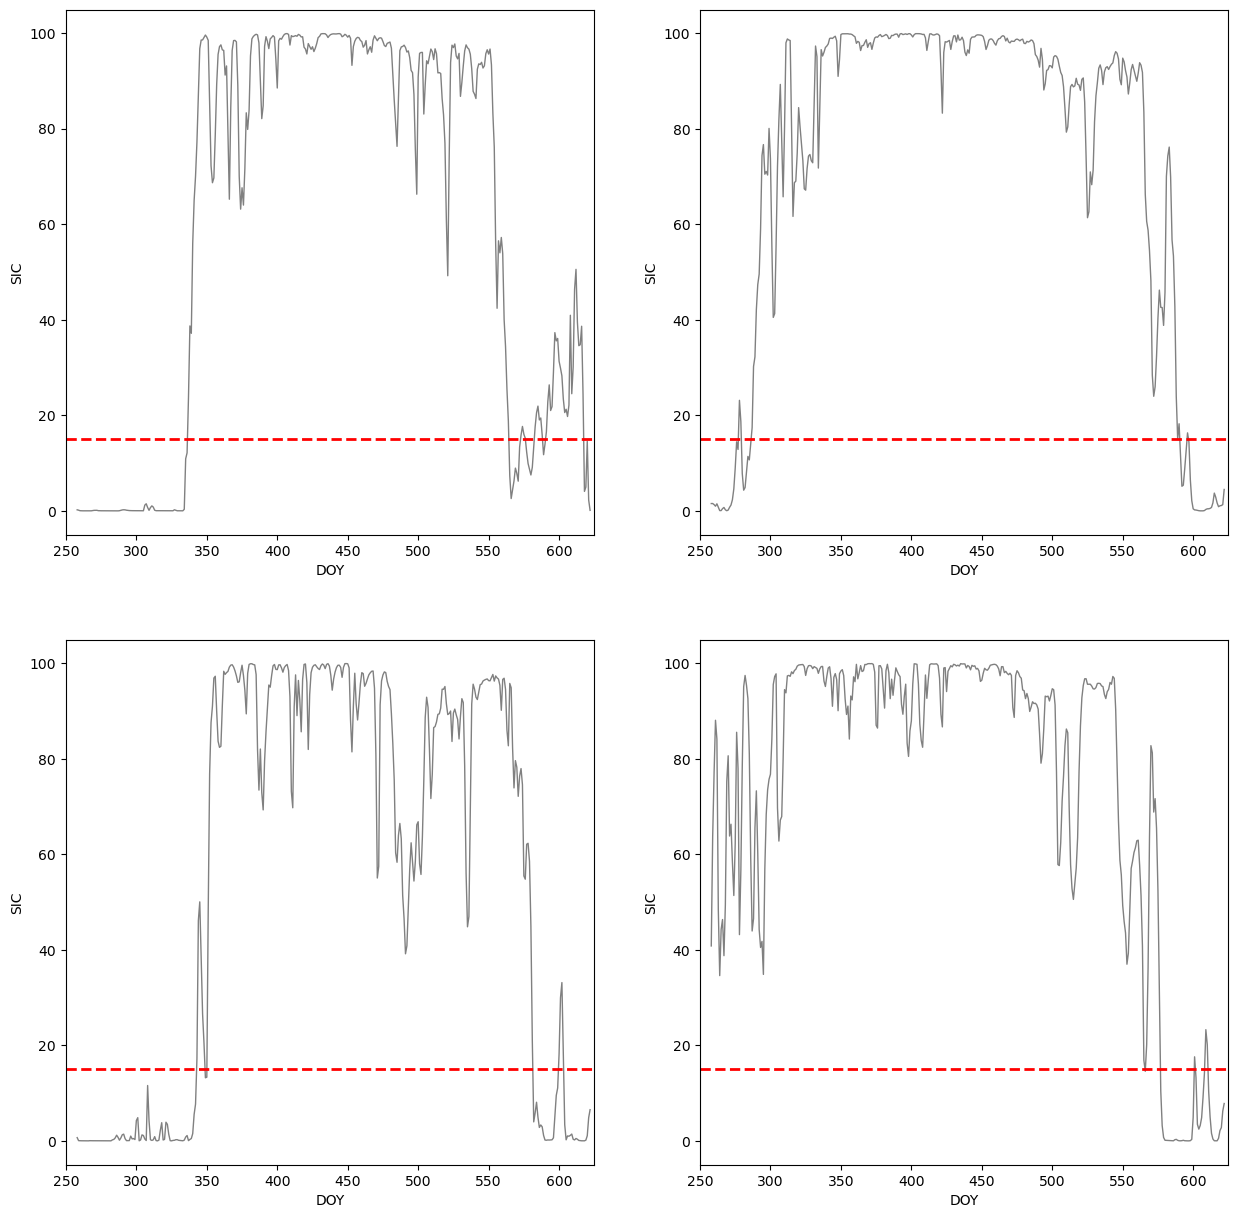

In [11]:
# TEST this - create figure
fout = model+'_ice_season_stats_single_years'
#fig = plt.figure(figsize=(30,10))
fig = plt.figure(figsize=(15,15))

# Make subplot - note it's nrow x ncol x index (starting upper left) - 3 rows x 2 columns
ax = fig.add_subplot(2,2,1)
ax.plot(doy_ice_2,data_model_sic_yr.isel(years=0, member_id=0),color='grey',linestyle='-',linewidth=1)
plt.axhline(y=15, color='red', linestyle='--', linewidth=2)
plt.xlabel('DOY')
plt.ylabel('SIC')
plt.xlim([250,625.0])

ax = fig.add_subplot(2,2,2)
ax.plot(doy_ice_2,data_model_sic_yr.isel(years=3, member_id=0),color='grey',linestyle='-',linewidth=1)
plt.axhline(y=15, color='red', linestyle='--', linewidth=2)
plt.xlabel('DOY')
plt.ylabel('SIC')
plt.xlim([250,625.0])

ax = fig.add_subplot(2,2,3)
ax.plot(doy_ice_2,data_model_sic_yr.isel(years=7, member_id=0),color='grey',linestyle='-',linewidth=1)
plt.axhline(y=15, color='red', linestyle='--', linewidth=2)
plt.xlabel('DOY')
plt.ylabel('SIC')
plt.xlim([250,625.0])

ax = fig.add_subplot(2,2,4)
ax.plot(doy_ice_2,data_model_sic_yr.isel(years=19, member_id=0),color='grey',linestyle='-',linewidth=1)
plt.axhline(y=15, color='red', linestyle='--', linewidth=2)
plt.xlabel('DOY')
plt.ylabel('SIC')
plt.xlim([250,625.0])

# Finalize figure and save
#fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)

In [12]:
# calculate the stats by year and member

# preallocate some arrays
dor_array = np.zeros([nyrs,nens])
doa_array = np.zeros([nyrs,nens])
ice_array = np.zeros([nyrs,nens])
sum_array = np.zeros([ndays])

# loop through each year
for index, yy in enumerate(years_model):
    #print(index)
    # now loop through ensemble members
    for eindex, ee in enumerate(ensembles):
        #print(eindex)
        temp1 = data_model_sic_yr.isel(years = index, member_id = eindex)
        
        ### Calculate persistence - mask where the data is above 15% with zero and one
        temp2 = zeros.where(temp1 <= 15, 1)
        # loop through and sum that day with next four days values
        for dindex, dd in enumerate(temp1.doy_ice):
            #print(dindex)
            sum_array[dindex] = temp2.isel(doy_ice = slice(dindex,dindex+5)).sum(dim='doy_ice').values
        # get indices where this is equal to 5 - this means the SIC > 15% for at least 5 days 
        indices = np.where((sum_array == 5))
        indices = indices[0]
        npts = len(indices)
        
        ### Get day of ADVANCE        
        # Advance: FIRST index where the sum_array equals five
        if np.isnan(indices).all():
            #print("No indices - only possible if no days above 15%, so set to missing")
            doa = -999
            doa_array[index,eindex] = doa
        else:
            #print("Yes indices - this is the day of advance")
            doa = indices[0]
            doa_array[index,eindex] = doy_ice_2[doa]
        #print(doa)

        ### Get day of RETREAT       
        # If there was a day of advance
        if doa != -999:
            if np.isnan(indices).all():
                #print("No indices - only possible if all days are above 15%, so use last day of the year")
                dor = doy_ice_2[364]
                dor_array[index,eindex] = dor
            else:
                #print("Yes indices - 4 days after this is the DOA")
                dor = indices[npts-1]
                dor = dor+4
                dor_array[index,eindex] = doy_ice_2[dor]
        else:
            # if there was no DOA, then the DOR is also missing as there's no ice that year.
            dor = -999
            dor_array[index,eindex] = dor

        ### Calculate total Ice covered days - to deal with ephemeral advance or retreat      
        # Count only points where SIC > 15%
        ice_array[index,eindex] = len(zeros.where(temp1 >= 15, drop=True))

# convert the numpy array to xarray for easier manipulation
data_doa = xr.DataArray(doa_array,dims=('years','member_id'))
data_doa['years'] = years_model

data_dor = xr.DataArray(dor_array,dims=('years','member_id'))
data_dor['years'] = years_model

data_ice_year = xr.DataArray(ice_array,dims=('years','member_id'))
data_ice_year['years'] = years_model

In [13]:
# crop last year since we can't calculate for 2100
data_doa = data_doa.isel(years=slice(0,180))
data_dor = data_dor.isel(years=slice(0,180))
data_ice_year = data_ice_year.isel(years=slice(0,180))

In [14]:
# replace missing value of -999 with nan
data_doa = data_doa.where(data_doa >= 0)
data_dor = data_dor.where(data_dor >= 0)

## Process SIC ice season
- Ice season duration = (DOY_retreat - DOY_advance)
- Also use total # ice free days in case of false freeze ups

In [15]:
# calculate ice free season
ice_season = data_dor - data_doa

In [16]:
# set some limits on ice season - can't be more than 365 days or less than 0
ice_season = ice_season.where(ice_season >0, 0)
ice_season = ice_season.where(ice_season <365, 365)

## Plot

In [17]:
# set an output directory for figures
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/utqiagvik_analysis/version_5/'

In [18]:
yticks = np.arange(250,650,25)

yticks2 = np.arange(0,370,25)

In [19]:
# Year array from 1920-2099 - for plotting
years_model = np.arange(1920,2100,1)

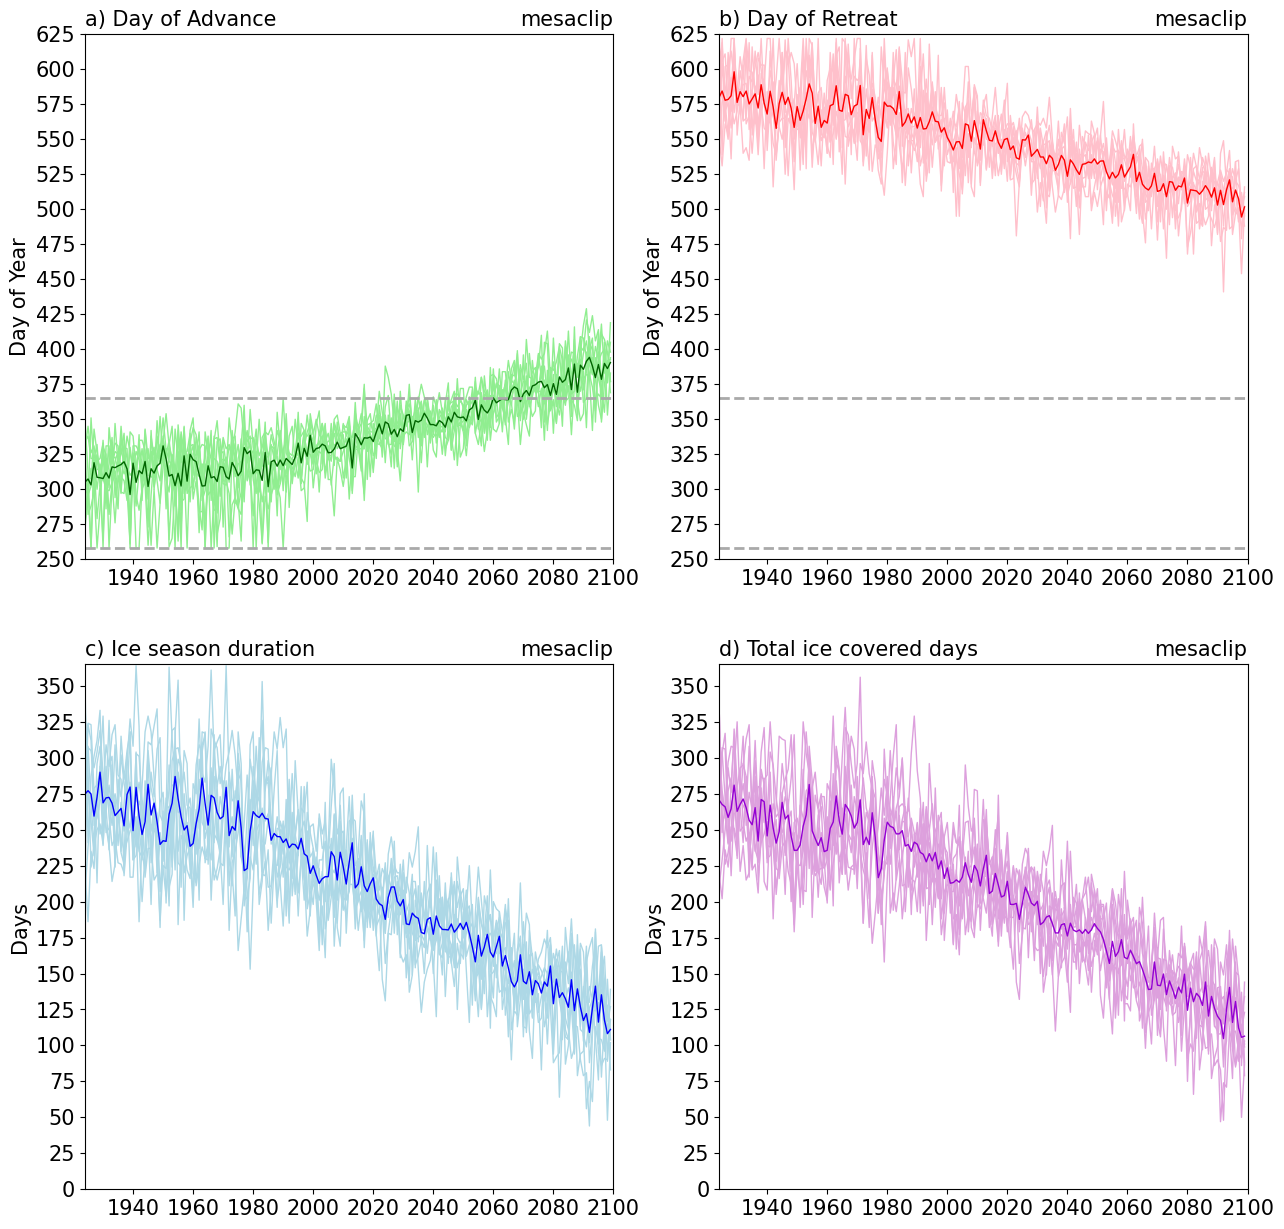

In [20]:
# create figure
fout = model+'_ice_season_stats'
#fig = plt.figure(figsize=(30,10))
fig = plt.figure(figsize=(15,15))

# Make subplot - note it's nrow x ncol x index (starting upper left) - 3 rows x 2 columns
## Day of Advance
ax = fig.add_subplot(2,2,1)
# Plot all ensembles
ax.plot(years_model,data_doa,color='lightgreen',linestyle='-',linewidth=1)
ax.plot(years_model,data_doa.mean(dim='member_id'),color='darkgreen',linestyle='-',linewidth=1)
# modify labels and legend
plt.axhline(y=258, color='darkgrey', linestyle='--', linewidth=2)
plt.axhline(y=365, color='darkgrey', linestyle='--', linewidth=2)
plt.title('a) Day of Advance',loc='left',fontsize=15)
plt.title(model,loc='right',fontsize=15)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('Day of Year',fontsize=15)
plt.yticks(yticks,fontsize=15)
plt.ylim([250,625.0])

## Day of Retreat
ax = fig.add_subplot(2,2,2)
# Plot all ensembles
ax.plot(years_model,data_dor,color='pink',linestyle='-',linewidth=1)
ax.plot(years_model,data_dor.mean(dim='member_id'),color='red',linestyle='-',linewidth=1)
# modify labels and legend
plt.axhline(y=258, color='darkgrey', linestyle='--', linewidth=2)
plt.axhline(y=365, color='darkgrey', linestyle='--', linewidth=2)
plt.title('b) Day of Retreat',loc='left',fontsize=15)
plt.title(model,loc='right',fontsize=15)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('Day of Year',fontsize=15)
plt.yticks(yticks,fontsize=15)
plt.ylim([250,625.0])

## Ice season duration
ax = fig.add_subplot(2,2,3)
# Plot all ensembles
ax.plot(years_model,ice_season,color='lightblue',linestyle='-',linewidth=1)
ax.plot(years_model,ice_season.mean(dim='member_id'),color='blue',linestyle='-',linewidth=1)
# modify labels and legend
plt.title('c) Ice season duration',loc='left',fontsize=15)
plt.title(model,loc='right',fontsize=15)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('Days',fontsize=15)
plt.yticks(yticks2,fontsize=15)
plt.ylim([0,365.0])

## Total Ice days
ax = fig.add_subplot(2,2,4)
# Plot all ensembles
ax.plot(years_model,data_ice_year,color='plum',linestyle='-',linewidth=1)
ax.plot(years_model,data_ice_year.mean(dim='member_id'),color='darkviolet',linestyle='-',linewidth=1)
# modify labels and legend
plt.title('d) Total ice covered days',loc='left',fontsize=15)
plt.title(model,loc='right',fontsize=15)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('Days',fontsize=15)
plt.yticks(yticks2,fontsize=15)
plt.ylim([0,365.0])

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)

## Save Data in Netcdf files

In [21]:
# add all data to a single data array
ds_out = xr.Dataset()

ds_out['DOA'] = data_doa.mean(dim='member_id')
ds_out['DOR'] = data_dor.mean(dim='member_id')
ds_out['ice_season'] = ice_season.mean(dim='member_id')
ds_out['ice_days'] = data_ice_year.mean(dim='member_id')

# change the attributes
ds_out.attrs['author'] = 'Alice DuVivier'
ds_out.attrs['date_processed'] = datetime.now().strftime('%Y-%m-%d')
ds_out.attrs['contents'] = f'CESM2-LE sea ice statistics for ocean point nearest Utqiagvik'

ds_out


<xarray.Dataset> Size: 7kB
Dimensions:     (years: 180)
Coordinates:
  * years       (years) int64 1kB 1920 1921 1922 1923 ... 2096 2097 2098 2099
Data variables:
    DOA         (years) float64 1kB 305.2 305.9 296.9 ... 389.9 386.2 390.6
    DOR         (years) float64 1kB 592.1 569.9 587.2 ... 507.6 494.4 501.7
    ice_season  (years) float64 1kB 286.9 264.0 290.3 ... 117.7 108.2 111.1
    ice_days    (years) float64 1kB 274.2 265.0 280.0 ... 112.3 105.7 106.4
Attributes:
    author:          Alice DuVivier
    date_processed:  2026-04-07
    contents:        CESM2-LE sea ice statistics for ocean point nearest Utqi...

In [22]:
# Print the dimensions
print("Dimensions:")
for dim in ds_out.dims:
    print(f"\t{dim}: {ds_out[dim].values.shape}")

# Print the coordinates
print("Coordinates:")
for coord in ds_out.coords:
    print(f"\t{coord}:")
    print(f"\t\t{ds_out.coords[coord].values}")
    
# Print the attributes
print("Attributes:")
for attr in ds_out.attrs:
    print(f"\t{attr}: {ds_out.attrs[attr]}")
    

Dimensions:
	years: (180,)
Coordinates:
	years:
		[1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056 2057 2058 2059
 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070 2071 2072 2073
 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084 2085 2086 2087
 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098 2099]
Attributes:
	author: Alice DuVivier


In [23]:
# calculate the size of the dataset in GB
size_gb = ds_out.nbytes / (1024**3)
print(f"The dataset is approximately {size_gb:.2f} GB.")


The dataset is approximately 0.00 GB.


In [24]:
path_out = './'
file_out = model+'_Utqigvik_1920-2100_ice_statistics.nc'
fout = path_out + file_out

In [25]:
print(fout)

./mesaclip_Utqigvik_1920-2100_ice_statistics.nc


In [26]:
# Export the dataset to NetCDF with all attributes and coordinates
ds_out.to_netcdf(fout)